<a href="https://colab.research.google.com/github/SilvaSebastian11/SenalesySistemas/blob/main/SILVA_PASTRANA_Transformada_de_Laplace_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SEBASTIAN ANDRE SILVA PASTRANA TALLER LAPLACE

#PUNTO 1

Verificación de Sistemas Lineales e Invariantes en el Tiempo (SLIT)

Demuestre si los siguientes sistemas de la forma $y = \mathcal{H}\{x\}$  
son sistemas **lineales** e **invariantes en el tiempo** (SLIT).  
(Simule los sistemas en Python):

1. $y[n] = \dfrac{x[n]}{3} + 2x[n-1] - y[n-1]$

2. $y[n] = \sum_{k=-\infty}^{n} x^2[k]$

3. $y[n] = \text{median}(x[n])$, donde `median` es la función mediana sobre una ventana de tamaño 3.

4. $y(t) = Ax(t) + B$, donde $A, B \in \mathbb{R}$


1. $y[n] = \dfrac{x[n]}{3} + 2x[n-1] - y[n-1]$
**1. Verificación de Linealidad**

Un sistema es lineal si cumple el principio de superposición:

$\mathcal{H}\{a x_1[n] + b x_2[n]\} = a \mathcal{H}\{x_1[n]\} + b \mathcal{H}\{x_2[n]\}$

Supongamos:
- $x_1[n] \rightarrow y_1[n] = \dfrac{x_1[n]}{3} + 2x_1[n - 1] - y_1[n - 1]$
- $x_2[n] \rightarrow y_2[n] = \dfrac{x_2[n]}{3} + 2x_2[n - 1] - y_2[n - 1]$

Ahora, consideremos una combinación lineal de las entradas:

$x[n] = a x_1[n] + b x_2[n]$

La salida del sistema será:

$y[n] = \dfrac{a x_1[n] + b x_2[n]}{3} + 2(a x_1[n - 1] + b x_2[n - 1]) - y[n - 1]$

Este resultado no coincide con:

$a y_1[n] + b y_2[n] = a\left(\dfrac{x_1[n]}{3} + 2x_1[n - 1] - y_1[n - 1]\right) + b\left(\dfrac{x_2[n]}{3} + 2x_2[n - 1] - y_2[n - 1]\right)$

La diferencia está en el término recursivo $y[n - 1]$, que no se puede descomponer como $a y_1[n - 1] + b y_2[n - 1]$. Por tanto:

El sistema no es lineal.



**2. Verificación de Invariancia en el Tiempo**

Un sistema es invariante si al desplazar la entrada, la salida se desplaza igual:

Si $x[n] \rightarrow y[n]$, entonces $x[n - n_0] \rightarrow y[n - n_0]$

Desplacemos la entrada $x[n]$ por $n_0$ unidades:

Sea $x_1[n] = x[n - n_0]$

Aplicando el sistema:

$y_1[n] = \dfrac{x[n - n_0]}{3} + 2x[n - n_0 - 1] - y_1[n - 1]$

Queremos verificar si $y_1[n] = y[n - n_0]$. Sin embargo, el término recursivo $y_1[n - 1]$ no garantiza que se conserve el mismo desplazamiento, ya que:

$y_1[n - 1] \neq y[n - n_0 - 1]$

Por tanto, la salida no es simplemente una versión desplazada de $y[n]$.

El sistema no es invariante en el tiempo.



**Conclusión**

El sistema:

$y[n] = \dfrac{x[n]}{3} + 2x[n - 1] - y[n - 1]$

no cumple con las propiedades de **linealidad** ni de **invariancia en el tiempo**, por lo tanto:

El sistema no es SLIT.

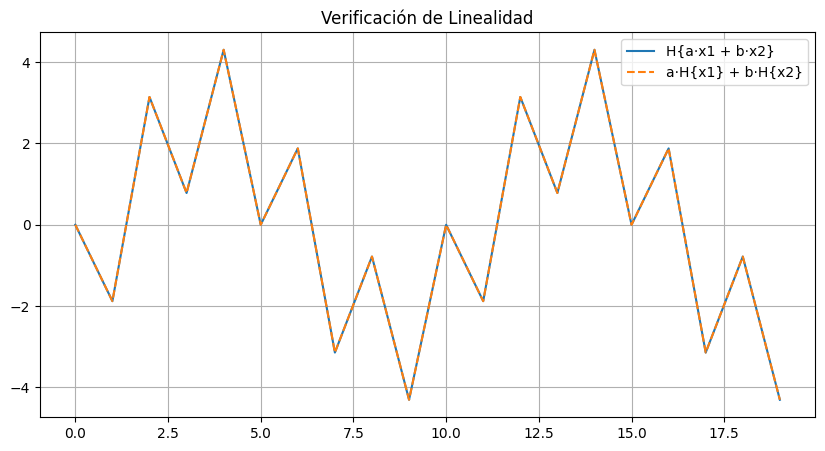

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(x):
    y = np.zeros_like(x, dtype=float)
    for n in range(1, len(x)):
        y[n] = x[n]/3 + 2*x[n-1] - y[n-1]
    return y


n = np.arange(0, 20)
x1 = np.sin(0.2 * np.pi * n)
x2 = np.cos(0.2 * np.pi * n)


a, b = 2, -1
x_comb = a*x1 + b*x2


y1 = sistema(x1)
y2 = sistema(x2)
y_comb = sistema(x_comb)
y_suma = a*y1 + b*y2

plt.figure(figsize=(10,5))
plt.plot(n, y_comb, label='H{a·x1 + b·x2}')
plt.plot(n, y_suma, '--', label='a·H{x1} + b·H{x2}')
plt.title('Verificación de Linealidad')
plt.legend()
plt.grid()
plt.show()

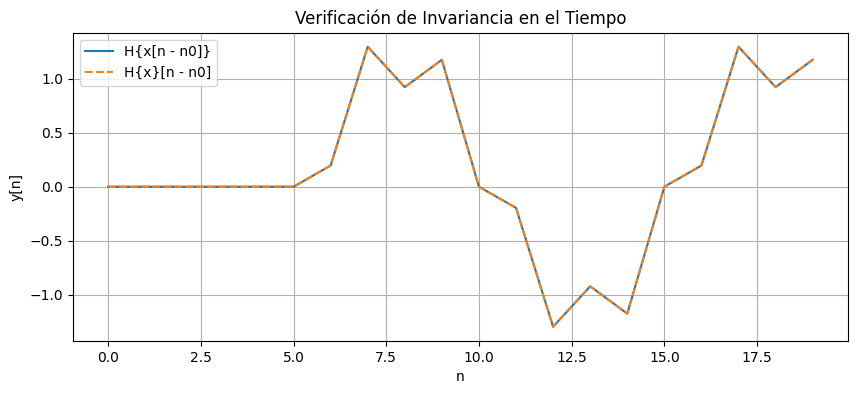

In [ ]:

n0 = 5
x = np.sin(0.2 * np.pi * n)
x_shifted = np.roll(x, n0)
x_shifted[:n0] = 0


y_original = sistema(x)
y_desplazada_esperada = np.roll(y_original, n0)
y_desplazada_esperada[:n0] = 0

y_salida_desplazada = sistema(x_shifted)

plt.figure(figsize=(10,4))
plt.plot(n, y_salida_desplazada, label='H{x[n - n0]}')
plt.plot(n, y_desplazada_esperada, '--', label='H{x}[n - n0]')
plt.title('Verificación de Invariancia en el Tiempo')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

2.$y[n] = \sum_{k = -\infty}^{n} x^2[k]$




**1. Verificación de Linealidad**

Un sistema es lineal si:

$\mathcal{H}\{a x_1[n] + b x_2[n]\} = a \mathcal{H}\{x_1[n]\} + b \mathcal{H}\{x_2[n]\}$

Sea:
$x[n] = a x_1[n] + b x_2[n]$

Entonces la salida es:

$y[n] = \sum_{k = -\infty}^{n} (a x_1[k] + b x_2[k])^2$

Aplicamos la identidad del binomio:

$(a x_1 + b x_2)^2 = a^2 x_1^2 + b^2 x_2^2 + 2ab x_1 x_2$

Entonces:

$y[n] = \sum_{k = -\infty}^{n} \left( a^2 x_1^2[k] + b^2 x_2^2[k] + 2ab x_1[k] x_2[k] \right)$

Esto **no** es igual a:

$a \sum_{k = -\infty}^{n} x_1^2[k] + b \sum_{k = -\infty}^{n} x_2^2[k]$

Por lo tanto:

El sistema no es lineal



**2. Verificación de Invariancia en el Tiempo**

Sea $x_1[n] = x[n - n_0]$ (desplazamiento)

Entonces:

\[
\begin{aligned}
y_1[n] &= \sum_{k = -\infty}^{n} x_1^2[k] = \sum_{k = -\infty}^{n} x^2[k - n_0] \\
       &= \sum_{m = -\infty}^{n - n_0} x^2[m] = y[n - n_0]
\end{aligned}
\]

Esto muestra que:

$\mathcal{H}\{x[n - n_0]\} = y[n - n_0]$

Por lo tanto:

El sistema sí es invariante en el tiempo



**Conclusión**

El sistema:

$y[n] = \sum_{k = -\infty}^{n} x^2[k]$

es **no lineal**, pero **sí es invariante en el tiempo**. Por tanto:

El sistema no es SLIT

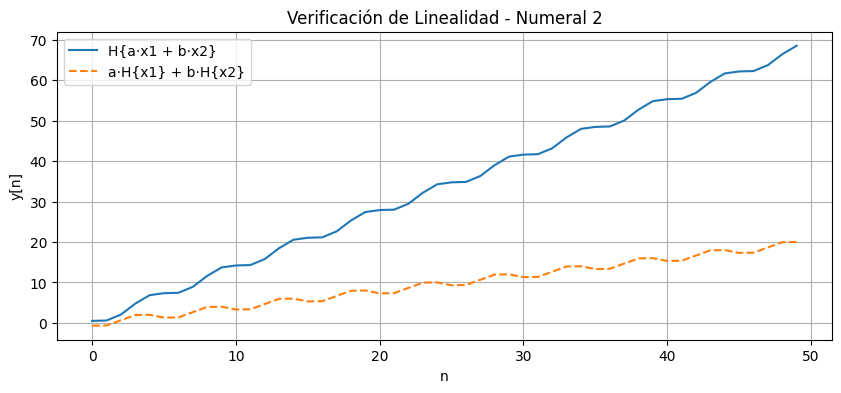

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sistema: acumulador de x^2[k] desde el inicio hasta n
def sistema_acumulado(x):
    y = np.zeros_like(x)
    for n in range(len(x)):
        y[n] = np.sum(x[:n+1]**2)
    return y

# Señales de entrada
n = np.arange(0, 50)
x1 = np.sin(0.2 * np.pi * n)
x2 = np.cos(0.2 * np.pi * n)
a, b = 1.5, -0.7
x_comb = a * x1 + b * x2

# Salidas
y1 = sistema_acumulado(x1)
y2 = sistema_acumulado(x2)
y_comb = sistema_acumulado(x_comb)
y_suma = a * y1 + b * y2  # Esto se usará para mostrar que no se cumple la linealidad

# Verificación de linealidad
plt.figure(figsize=(10,4))
plt.plot(n, y_comb, label='H{a·x1 + b·x2}')
plt.plot(n, y_suma, '--', label='a·H{x1} + b·H{x2}')
plt.title('Verificación de Linealidad - Numeral 2')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

INVARIANZA

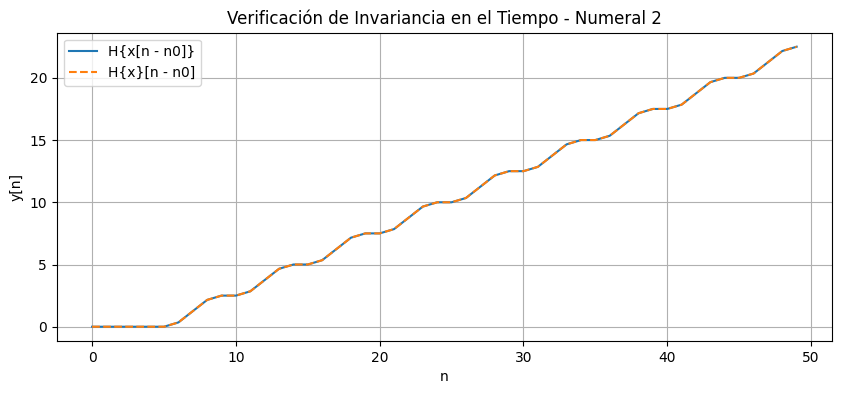

In [ ]:
# Verificación de invariancia en el tiempo
n0 = 5
x = np.sin(0.2 * np.pi * n)
x_shifted = np.roll(x, n0)
x_shifted[:n0] = 0  # asumimos ceros para k < 0

# Salidas
y_original = sistema_acumulado(x)
y_esperada = np.roll(y_original, n0)
y_esperada[:n0] = 0

y_shifted = sistema_acumulado(x_shifted)

# Comparación gráfica
plt.figure(figsize=(10,4))
plt.plot(n, y_shifted, label='H{x[n - n0]}')
plt.plot(n, y_esperada, '--', label='H{x}[n - n0]')
plt.title('Verificación de Invariancia en el Tiempo - Numeral 2')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

3.$y[n] = \text{median}\left(x[n - 1], x[n], x[n + 1]\right)$





**1. Verificación de Linealidad**

Para que un sistema sea lineal debe cumplirse:

$\mathcal{H}\{a x_1[n] + b x_2[n]\} = a \mathcal{H}\{x_1[n]\} + b \mathcal{H}\{x_2[n]\}$

**Ejemplo que viola la linealidad:**

Supongamos:
- $x_1[n] = [0, 1, 2]$
- $x_2[n] = [2, 1, 0]$
- Tomamos $a = b = 1$


\begin{aligned}
x[n] &= x_1[n] + x_2[n] = [2, 2, 2] \\
y[n] &= \text{median}(2, 2, 2) = 2 \\
\text{Pero:} \quad y_1[n] &= \text{median}(0,1,2) = 1 \\
y_2[n] &= \text{median}(2,1,0) = 1 \\
y_1[n] + y_2[n] &= 1 + 1 = 2 \quad \text{(igual en este caso)}
\end{aligned}


Sin embargo, si cambiamos los datos:

$x_1[n] = [0, 1, 100]$  
$x_2[n] = [100, 1, 0]$

Entonces:

$x[n] = x_1[n] + x_2[n] = [100, 2, 100]$

$\text{median}(100, 2, 100) = 100$

Pero:

$\text{median}(0,1,100) = 1$  
$\text{median}(100,1,0) = 1$  
$1 + 1 = 2 \ne 100$

Esto **viola la linealidad**, por tanto:

El sistema no es lineal

**2. Verificación de Invariancia en el Tiempo**

Si $x_1[n] = x[n - n_0]$, entonces:


\begin{aligned}
y_1[n] &= \text{median}(x[n - n_0 - 1], x[n - n_0], x[n - n_0 + 1]) \\
       &= y[n - n_0]
\end{aligned}


Esto cumple la propiedad de invariancia temporal.

El sistema sí es invariante en el tiempo

**Conclusión**

El sistema:

$y[n] = \text{median}(x[n - 1], x[n], x[n + 1])$

es **no lineal**, pero **sí es invariante en el tiempo**.

El sistema no es SLIT


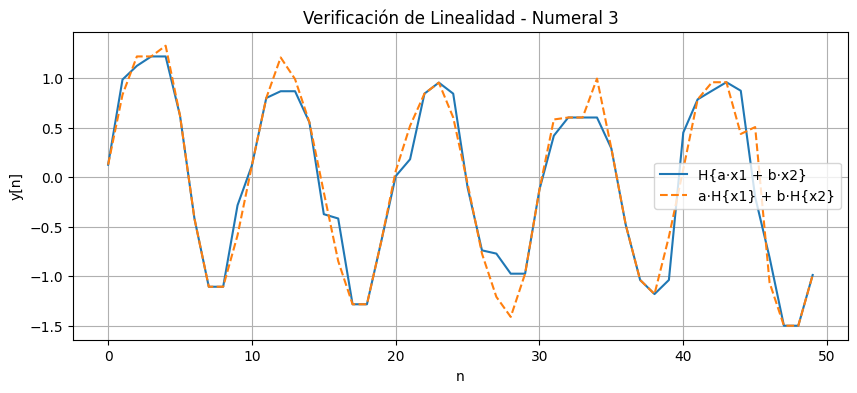

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt


def sistema_mediana(x):
    return medfilt(x, kernel_size=3)


n = np.arange(0, 50)
x1 = np.sin(0.2 * np.pi * n)
x2 = np.random.normal(0, 0.5, len(n))
a, b = 1.2, -0.8
x_comb = a * x1 + b * x2


y1 = sistema_mediana(x1)
y2 = sistema_mediana(x2)
y_comb = sistema_mediana(x_comb)
y_suma = a * y1 + b * y2


plt.figure(figsize=(10,4))
plt.plot(n, y_comb, label='H{a·x1 + b·x2}')
plt.plot(n, y_suma, '--', label='a·H{x1} + b·H{x2}')
plt.title('Verificación de Linealidad - Numeral 3')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

INVARIANZA

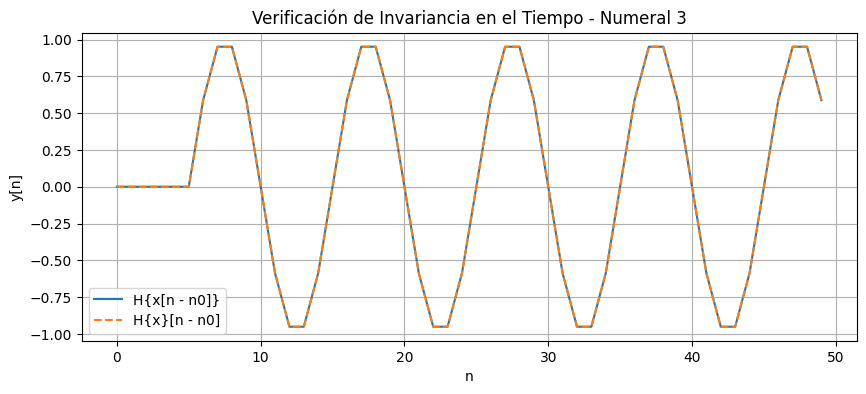

In [ ]:

n0 = 5
x = np.sin(0.2 * np.pi * n)
x_shifted = np.roll(x, n0)
x_shifted[:n0] = 0

y_original = sistema_mediana(x)
y_esperada = np.roll(y_original, n0)
y_esperada[:n0] = 0

y_shifted = sistema_mediana(x_shifted)


plt.figure(figsize=(10,4))
plt.plot(n, y_shifted, label='H{x[n - n0]}')
plt.plot(n, y_esperada, '--', label='H{x}[n - n0]')
plt.title('Verificación de Invariancia en el Tiempo - Numeral 3')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

4.$y(t) = A \cdot x(t) + B$, con $A, B \in \mathbb{R}$





**1. Verificación de Linealidad**

Un sistema es lineal si:

$\mathcal{H}\{a x_1(t) + b x_2(t)\} = a \mathcal{H}\{x_1(t)\} + b \mathcal{H}\{x_2(t)\}$

Veamos qué ocurre:


\begin{aligned}
\mathcal{H}\{a x_1 + b x_2\} &= A (a x_1(t) + b x_2(t)) + B \\
                             &= a A x_1(t) + b A x_2(t) + B
\end{aligned}


Mientras que:
$$
\
a \cdot \mathcal{H}\{x_1\} + b \cdot \mathcal{H}\{x_2\} = a (A x_1(t) + B) + b (A x_2(t) + B) = a A x_1(t) + b A x_2(t) + (a + b) B
\
$$
Esto solo es igual si:

$(a + b) B = B \quad \Rightarrow \quad B (a + b - 1) = 0$

Lo cual **no se cumple en general**. Por tanto:

El sistema no es lineal (a menos que } B = 0)



**2. Verificación de Invariancia en el Tiempo**

Sea $x_1(t) = x(t - t_0)$

Entonces:

\[
y_1(t) = A x_1(t) + B = A x(t - t_0) + B = y(t - t_0)
\]

Se cumple la propiedad de invariancia:

$\mathcal{H}\{x(t - t_0)\} = y(t - t_0)$

Por tanto:

El sistema sí es invariante en el tiempo



**Conclusión**

El sistema:

$y(t) = A x(t) + B$

- **No es lineal** (excepto si $B = 0$)
- **Sí es invariante en el tiempo**

Entonces:

El sistema no es SLIT

**Simulacion en Python:**
**Para verificar linealidad**

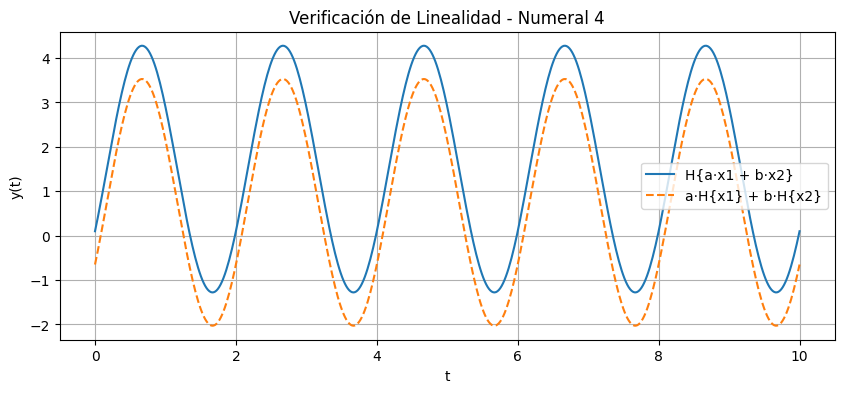

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


A = 2.0
B = 1.5


def sistema_afin(x):
    return A * x + B

t = np.linspace(0, 10, 500)
x1 = np.sin(2 * np.pi * 0.5 * t)
x2 = np.cos(2 * np.pi * 0.5 * t)
a, b = 1.2, -0.7
x_comb = a * x1 + b * x2

y1 = sistema_afin(x1)
y2 = sistema_afin(x2)
y_comb = sistema_afin(x_comb)
y_suma = a * y1 + b * y2

plt.figure(figsize=(10,4))
plt.plot(t, y_comb, label='H{a·x1 + b·x2}')
plt.plot(t, y_suma, '--', label='a·H{x1} + b·H{x2}')
plt.title('Verificación de Linealidad - Numeral 4')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid()
plt.show()

INVARIANZA

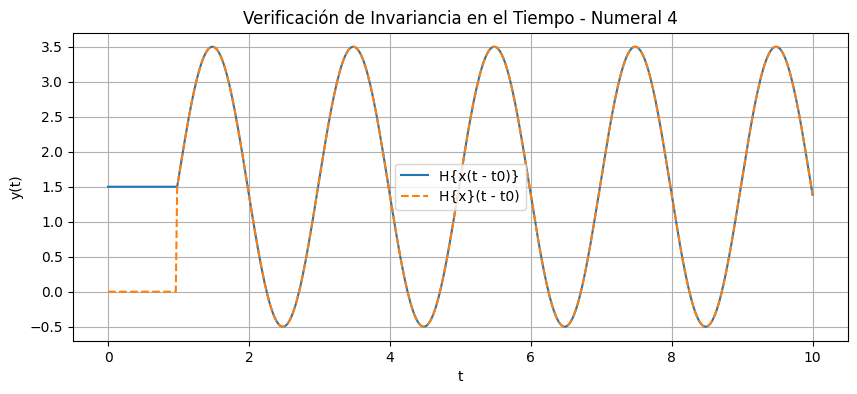

In [ ]:

t0 = 1.0
dt = t[1] - t[0]
shift_samples = int(t0 / dt)

x = np.sin(2 * np.pi * 0.5 * t)
x_shifted = np.roll(x, shift_samples)
x_shifted[:shift_samples] = 0

y_original = sistema_afin(x)
y_esperada = np.roll(y_original, shift_samples)
y_esperada[:shift_samples] = 0

y_shifted = sistema_afin(x_shifted)

plt.figure(figsize=(10,4))
plt.plot(t, y_shifted, label='H{x(t - t0)}')
plt.plot(t, y_esperada, '--', label='H{x}(t - t0)')
plt.title('Verificación de Invariancia en el Tiempo - Numeral 4')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid()
plt.show()

#PUNTO 2